# 02. Dataset Preprocessing

This notebook builds the versioned, model-agnostic clean dataset used by the project experiments.

**Responsibilities:**
- collect and quality-check raw Coffee and Rice images;
- create reproducible, domain-preserving train/validation/test splits;
- copy source-resolution images without changing pixels or polygon coordinates;
- export domain manifests, class mappings, and clean COCO annotations.

Model-specific resizing, augmentation, sampling, normalization, and training configuration remain in each experiment notebook.

**Split ratio:** 70% train - 15% validation - 15% test, stratified independently within each domain.

---

### Quick index

1. Configure source and output roots
2. Collect raw image metadata
3. Apply quality filters
4. Create leakage-aware domain splits
5. Export clean source-resolution images and COCO annotations
6. Save manifests and dataset metadata

---

## 1. Environment and Configuration

This cell configures imports, reproducibility, and source/output roots for the complete preprocessing run.

**Principles:**
- read the raw dataset from one explicit source root;
- write a versioned clean dataset to `data/clean/<dataset_version>/`;
- never modify the raw dataset.

In [1]:
# ============================================================
# Environment setup
# ============================================================
import os
import sys
import json
import hashlib
import warnings
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile, UnidentifiedImageError
import shutil
from sklearn.model_selection import train_test_split

import torch
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Find project root from current working directory
def find_project_root() -> Path:
    cwd = Path(os.getcwd())
    for candidate in [cwd, cwd.parent, cwd.parent.parent]:
        if ((candidate / "pyproject.toml").is_file()
                and (candidate / "src").is_dir()):
            return candidate
    return cwd


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import COFFEE_CLASSES, RANDOM_SEED, RICE_CLASSES
from src.reproducibility import set_seed

set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

RAW_DATA_ROOT = Path(os.environ.get("DATASET_SOURCE_ROOT", PROJECT_ROOT / "data" / "raw" / "coffee_rice_dataset"))
DATASET_VERSION = os.environ.get("DATASET_VERSION", "coffee_rice_v001")
CLEAN_ROOT = Path(os.environ.get("CLEAN_DATASET_ROOT", PROJECT_ROOT / "data" / "clean" / DATASET_VERSION))
META_DIR = CLEAN_ROOT / "metadata"
IMG_OUT_DIR = CLEAN_ROOT

RICE_RAW_DIR = RAW_DATA_ROOT / "rice_leaf_disease"
COFFEE_RAW_DIR = RAW_DATA_ROOT / "coffee_leaf_disease"

COFFEE_FOLDER_TO_LABEL = {str(i): name for i, name in enumerate(COFFEE_CLASSES)}
VALID_EXTS = {".jpg", ".jpeg", ".png", ".webp"}

for path in [CLEAN_ROOT, META_DIR, IMG_OUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data dir: {RAW_DATA_ROOT}")
print(f"Clean dataset dir: {CLEAN_ROOT}")

Project root: /Users/tuananhduong/Projects/plant-disease-ai
Raw data dir: /Users/tuananhduong/Projects/plant-disease-ai/data/raw/coffee_rice_dataset
Clean dataset dir: /Users/tuananhduong/Projects/plant-disease-ai/data/clean/coffee_rice_v001


/Users/tuananhduong/Projects/plant-disease-ai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## 2. Collect Raw Metadata

This step collects metadata from the separate Rice and Coffee raw domains, including:
- domain and canonical label;
- source and COCO-relative paths;
- image dimensions and color mode;
- basic file and validity information.

The unified table is the input to quality filtering and domain-preserving splitting.

### What Is Metadata?

Metadata describes each image, including its path, dimensions, class label, domain, and basic quality fields.

### Why Use a Unified Metadata Table?

The project uses two independent datasets with different folder structures. A shared DataFrame provides:
- **centralized inventory** for both domains;
- **consistent statistics** for class and image properties;
- **one input table** for quality filtering and splitting.

### The `safe_image_size` Helper

The helper opens each image with PIL and returns `NaN` metadata for unreadable files instead of stopping the inventory step.

In [2]:
# ============================================================
# Build unified metadata table from raw folders
# ============================================================
def safe_image_size(image_path: Path):
    try:
        with Image.open(image_path) as img:
            width, height = img.size
            mode = img.mode
        return width, height, mode, True
    except (UnidentifiedImageError, OSError, ValueError):
        return np.nan, np.nan, "invalid", False


def collect_domain_records(
    domain: str,
    domain_dir: Path,
    folder_to_label: Dict[str, str],
    start_index: int = 0,
    valid_exts: set = VALID_EXTS,
) -> pd.DataFrame:
    records: List[dict] = []
    sample_index = start_index

    for folder_name, label_name in folder_to_label.items():
        class_dir = domain_dir / folder_name
        if not class_dir.exists():
            print(f"[WARN] Missing class folder: {class_dir}")
            continue

        image_files = [
            p for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in valid_exts
        ]

        for image_path in image_files:
            width, height, mode, is_valid = safe_image_size(image_path)
            records.append({
                "sample_id": f"{domain}_{sample_index:07d}",
                "domain": domain,
                "label": label_name,
                "class_folder": folder_name,
                "file_name": image_path.name,
                "raw_coco_file_name": f"{folder_name}/{image_path.name}",
                "image_path": str(image_path),
                "relative_path": str(image_path.relative_to(PROJECT_ROOT)).replace("\\", "/"),
                "file_ext": image_path.suffix.lower(),
                "file_size_bytes": image_path.stat().st_size,
                "width": width,
                "height": height,
                "aspect_ratio": (width / height) if is_valid and height else np.nan,
                "color_mode": mode,
                "is_valid_image": is_valid,
            })
            sample_index += 1

    return pd.DataFrame(records)


rice_map = {cls: cls for cls in RICE_CLASSES}
coffee_map = {str(i): label for i, label in enumerate(COFFEE_CLASSES)}

rice_meta = collect_domain_records(
    domain="rice",
    domain_dir=RICE_RAW_DIR,
    folder_to_label=rice_map,
    start_index=0,
    valid_exts=VALID_EXTS,
)
coffee_meta = collect_domain_records(
    domain="coffee",
    domain_dir=COFFEE_RAW_DIR,
    folder_to_label=coffee_map,
    start_index=len(rice_meta),
    valid_exts=VALID_EXTS,
)

meta_df = pd.concat([rice_meta, coffee_meta], ignore_index=True)
meta_df["domain_label"] = meta_df["domain"] + "::" + meta_df["label"]

display(meta_df.head())
print(f"Total rows: {len(meta_df):,}")
print(f"Invalid images (open failed): {(~meta_df['is_valid_image']).sum():,}")

summary_table = (
    meta_df.groupby(["domain", "label"], as_index=False)
    .agg(
        n_images=("sample_id", "count"),
        mean_width=("width", "mean"),
        mean_height=("height", "mean"),
    )
    .sort_values(["domain", "label"])
    .round(1)
)
display(summary_table)

,sample_id,domain,label,class_folder,file_name,raw_coco_file_name,image_path,relative_path,file_ext,file_size_bytes,width,height,aspect_ratio,color_mode,is_valid_image,domain_label
0,rice_0000000,rice,BrownSpot,BrownSpot,img_794b5efd.jpeg,BrownSpot/img_794b5efd.jpeg,/Users/tuananhduong/Projects/plant-disease-ai/...,data/raw/coffee_rice_dataset/rice_leaf_disease...,.jpeg,286173,960,1280,0.75,RGB,True,rice::BrownSpot
1,rice_0000001,rice,BrownSpot,BrownSpot,IMG_20190419_161510.jpg,BrownSpot/IMG_20190419_161510.jpg,/Users/tuananhduong/Projects/plant-disease-ai/...,data/raw/coffee_rice_dataset/rice_leaf_disease...,.jpg,2165360,1937,1937,1.00,RGB,True,rice::BrownSpot
2,rice_0000002,rice,BrownSpot,BrownSpot,IMG_20190420_185512.jpg,BrownSpot/IMG_20190420_185512.jpg,/Users/tuananhduong/Projects/plant-disease-ai/...,data/raw/coffee_rice_dataset/rice_leaf_disease...,.jpg,3165869,3120,3120,1.00,RGB,True,rice::BrownSpot
3,rice_0000003,rice,BrownSpot,BrownSpot,IMG_20190420_190123.jpg,BrownSpot/IMG_20190420_190123.jpg,/Users/tuananhduong/Projects/plant-disease-ai/...,data/raw/coffee_rice_dataset/rice_leaf_disease...,.jpg,2733589,3120,3120,1.00,RGB,True,rice::BrownSpot
4,rice_0000004,rice,BrownSpot,BrownSpot,img_446c8b4b.jpeg,BrownSpot/img_446c8b4b.jpeg,/Users/tuananhduong/Projects/plant-disease-ai/...,data/raw/coffee_rice_dataset/rice_leaf_disease...,.jpeg,138408,960,1280,0.75,RGB,True,rice::BrownSpot


Total rows: 7,300
Invalid images (open failed): 0


,domain,label,n_images,mean_width,mean_height
0,coffee,AlgalLeafSpot,969,963.1,1140.4
1,coffee,LeafMiner,1226,986.9,1149.4
2,coffee,PowderyMildew,268,943.3,1179.2
3,coffee,Rust,1416,966.6,1163.7
4,rice,BrownSpot,542,2136.1,2133.3
5,rice,Healthy,1503,2101.3,2097.6
6,rice,Hispa,583,2080.3,2066.7
7,rice,LeafBlast,793,1791.4,1788.3


---

## 3. Quality Filtering

The raw images are filtered before splitting:
- unreadable files are marked `invalid`;
- exact content duplicates are identified by MD5;
- optionally blurry images are identified by variance of Laplacian.

The blur threshold is computed by a low quantile within each domain/class group.

### 1. Invalid Images

An image is marked `invalid` when PIL cannot open it because the file is corrupt, malformed, or has an unsupported header.

### 2. Exact Duplicates — MD5 Hash

Exact byte-level duplicates are detected with an **MD5** digest:

$$\text{MD5}(\text{file\_bytes}) \rightarrow \text{128-bit hash string}$$

Files with the same digest have identical bytes. The first occurrence is retained and later occurrences are removed.

### 3. Blurry Images — Variance of Laplacian

The **Laplacian** measures second-order pixel-intensity variation and is commonly used as an edge signal:

$$L(x, y) = -4 \cdot I(x,y) + I(x{-}1,y) + I(x{+}1,y) + I(x,y{-}1) + I(x,y{+}1)$$

The **variance of Laplacian** (VoL) is used as a simple sharpness proxy:

$$\text{VoL} = \text{Var}(L(x,y)) = \frac{1}{N}\sum_{x,y}\left(L(x,y) - \bar{L}\right)^2$$

- **High VoL** usually indicates sharper images with more edge detail.
- **Low VoL** usually indicates blurrier images with less edge detail.

**Adaptive blur threshold:** the threshold uses the lower 2% quantile for each `domain::label` group. Groups with fewer than 40 images use the global threshold.

Hashing images:   0%|          | 0/7300 [00:00<?, ?it/s]

Scoring blur: 100%|██████████| 7300/7300 [02:52<00:00, 42.25it/s] 

Global blur threshold (q=0.02): 8.3284


,reason,count,ratio_percent
0,invalid,0,0.00
1,duplicate,1,0.01
2,blurry,150,2.05
3,kept,7149,97.93


,domain,label,n_images
0,coffee,AlgalLeafSpot,949
1,coffee,LeafMiner,1200
2,coffee,PowderyMildew,262
3,coffee,Rust,1387
4,rice,BrownSpot,531
5,rice,Healthy,1472
6,rice,Hispa,571
7,rice,LeafBlast,777


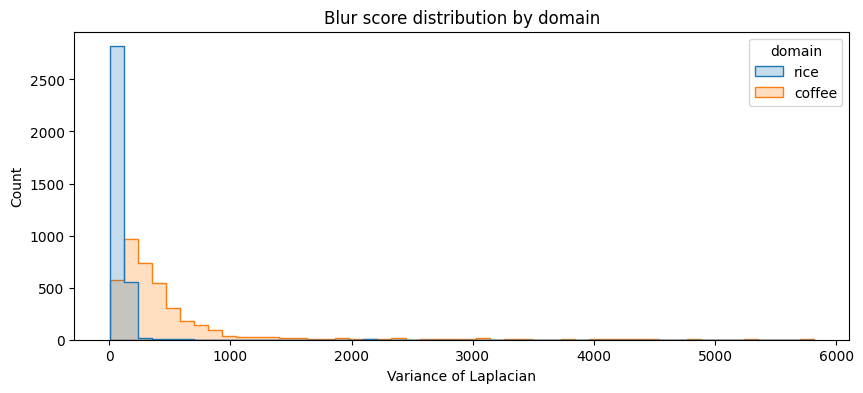

In [3]:
# ============================================================
# Data quality filtering
# ============================================================
BLUR_QUANTILE = 0.02
DROP_BLURRY = True


def compute_md5(file_path: str, chunk_size: int = 1 << 20) -> str:
    md5 = hashlib.md5()
    with open(file_path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            md5.update(chunk)
    return md5.hexdigest()


def compute_sha256(file_path: str, chunk_size: int = 1 << 20) -> str:
    sha256 = hashlib.sha256()
    with open(file_path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()


def estimate_blur_score(file_path: str) -> float:
    try:
        with Image.open(file_path) as img:
            gray = np.asarray(img.convert("L"), dtype=np.float32)
        if gray.shape[0] < 3 or gray.shape[1] < 3:
            return 0.0

        # Variance of Laplacian (discrete 4-neighborhood)
        lap = (
            -4.0 * gray[1:-1, 1:-1]
            + gray[:-2, 1:-1]
            + gray[2:, 1:-1]
            + gray[1:-1, :-2]
            + gray[1:-1, 2:]
        )
        return float(np.var(lap))
    except Exception:
        return np.nan


quality_df = meta_df.copy()
valid_idx = quality_df["is_valid_image"]

# File hash for duplicate detection
quality_df.loc[valid_idx, "md5"] = [
    compute_md5(p)
    for p in tqdm(quality_df.loc[valid_idx, "image_path"], desc="Hashing images")
]
quality_df.loc[valid_idx, "source_sha256"] = [
    compute_sha256(p)
    for p in tqdm(quality_df.loc[valid_idx, "image_path"], desc="Hashing images (SHA-256)")
]
quality_df["source_md5"] = quality_df["md5"]
quality_df["is_duplicate"] = quality_df["md5"].duplicated(keep="first")

# Blur score for quality control
quality_df.loc[valid_idx, "blur_score"] = [
    estimate_blur_score(p)
    for p in tqdm(quality_df.loc[valid_idx, "image_path"], desc="Scoring blur")
]

global_blur_threshold = quality_df.loc[valid_idx, "blur_score"].quantile(BLUR_QUANTILE)

def resolve_group_threshold(series: pd.Series) -> float:
    # Use class-specific threshold when enough samples are available.
    if series.notna().sum() >= 40:
        return float(series.quantile(BLUR_QUANTILE))
    return float(global_blur_threshold)

quality_df["blur_threshold"] = quality_df.groupby("domain_label")["blur_score"].transform(resolve_group_threshold)
quality_df["is_blurry"] = (quality_df["blur_score"] < quality_df["blur_threshold"]).fillna(False)

if DROP_BLURRY:
    keep_mask = quality_df["is_valid_image"] & (~quality_df["is_duplicate"]) & (~quality_df["is_blurry"])
else:
    keep_mask = quality_df["is_valid_image"] & (~quality_df["is_duplicate"])

clean_df = quality_df.loc[keep_mask].copy().reset_index(drop=True)

removed_summary = pd.DataFrame({
    "reason": ["invalid", "duplicate", "blurry", "kept"],
    "count": [
        int((~quality_df["is_valid_image"]).sum()),
        int(quality_df["is_duplicate"].sum()),
        int(quality_df["is_blurry"].sum()) if DROP_BLURRY else 0,
        int(len(clean_df)),
    ],
})
removed_summary["ratio_percent"] = (removed_summary["count"] / len(quality_df) * 100).round(2)

print(f"Global blur threshold (q={BLUR_QUANTILE:.2f}): {global_blur_threshold:.4f}")
display(removed_summary)

clean_dist = (
    clean_df.groupby(["domain", "label"], as_index=False)
    .agg(n_images=("sample_id", "count"))
    .sort_values(["domain", "label"])
)
display(clean_dist)

plt.figure(figsize=(10, 4))
sns.histplot(data=quality_df[quality_df["is_valid_image"]], x="blur_score", hue="domain", bins=50, element="step")
plt.title("Blur score distribution by domain")
plt.xlabel("Variance of Laplacian")
plt.ylabel("Count")
plt.show()

### Analysis: Quality-Filtering Results

#### Quality-Filtering Summary

The `removed_summary` table reports:

| Reason | Meaning |
|------------|---------|
| **Invalid** | Unreadable files; a large count should trigger a source audit. |
| **Duplicate** | Exact duplicate bytes removed to reduce split leakage. |
| **Blurry** | Lowest-quality samples below the group threshold. |
| **Kept** | Samples available for the fixed split. |

#### Blur-Score Distribution

The histogram of `blur_score` by domain helps identify domains with more low-sharpness samples:
- a left-shifted distribution suggests more low-sharpness images in that domain;
- the 2% threshold is conservative and removes only the lowest-quality tail;
- group-specific thresholds reduce bias against classes with naturally less texture.

---

## 4. Leakage-Aware Domain Split

The dataset is split using the following ratios:
- Train: 70%
- Validation: 15%
- Test: 15%

The split is stratified independently within each domain so Coffee and Rice remain separate.

The notebook checks overlap by both `sample_id` and `md5` after splitting.

### Data Leakage

**Data leakage** occurs when validation or test information enters training and produces an overly optimistic evaluation. Here, the key failure is the same image appearing in multiple splits.

### Stratified Split

A stratified split keeps the **class proportions** comparable across partitions:

$$\frac{|\text{class}_i \cap \text{train}|}{|\text{train}|} \approx \frac{|\text{class}_i|}{|\text{dataset}|}$$

The implementation stratifies independently within each domain and label so Coffee and Rice remain separate.

### Two-Step Split Procedure

To obtain 70/15/15:

1. **Step 1:** split train (70%) from the remaining 30% into `temp`.
2. **Step 2:** split `temp` equally into validation and test.

### Leakage Checks

After splitting, the notebook checks **overlap** by both `sample_id` and `md5`; all pairwise overlaps must be zero.

In [4]:
# ============================================================
# Stratified split: train / val / test
# ============================================================
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-9

def split_domain(domain_df: pd.DataFrame) -> pd.DataFrame:
    train_part, temp_part = train_test_split(
        domain_df, test_size=(1.0 - TRAIN_RATIO), random_state=RANDOM_SEED,
        stratify=domain_df["label"],
    )
    val_share = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
    val_part, test_part = train_test_split(
        temp_part, test_size=(1.0 - val_share), random_state=RANDOM_SEED,
        stratify=temp_part["label"],
    )
    return pd.concat([
        train_part.assign(split="train"),
        val_part.assign(split="val"),
        test_part.assign(split="test"),
    ], ignore_index=True)

split_df = pd.concat(
    [split_domain(domain_part.copy()) for _, domain_part in clean_df.groupby("domain", sort=True)],
    ignore_index=True,
)
train_df = split_df[split_df["split"] == "train"].copy()
val_df = split_df[split_df["split"] == "val"].copy()
test_df = split_df[split_df["split"] == "test"].copy()

# Leakage checks by unique id and by image content hash
def overlap_size(left: pd.DataFrame, right: pd.DataFrame, key: str) -> int:
    return len(set(left[key]) & set(right[key]))

print("Overlap checks (must be 0):")
print(f"sample_id train-val : {overlap_size(train_df, val_df, 'sample_id')}")
print(f"sample_id train-test: {overlap_size(train_df, test_df, 'sample_id')}")
print(f"sample_id val-test  : {overlap_size(val_df, test_df, 'sample_id')}")
print(f"md5 train-val       : {overlap_size(train_df, val_df, 'md5')}")
print(f"md5 train-test      : {overlap_size(train_df, test_df, 'md5')}")
print(f"md5 val-test        : {overlap_size(val_df, test_df, 'md5')}")

split_stats = (
    split_df.groupby(["split", "domain", "label"], as_index=False)
    .agg(n_images=("sample_id", "count"))
    .sort_values(["split", "domain", "label"])
)
display(split_stats)

global_split_ratio = (
    split_df["split"].value_counts(normalize=True)
    .rename("ratio")
    .mul(100)
    .round(2)
    .sort_index()
)
print("Global split ratio (%):")
print(global_split_ratio.to_string())

# Save initial manifests immediately after split to lock anti-leakage partitions
for column in ["image_path", "relative_path"]:
    split_df[column] = split_df[column].astype(str).str.replace("\\\\", "/", regex=False)

meta_export_cols = [
    "sample_id", "split", "domain", "label", "domain_label", "class_folder",
    "file_name", "image_path", "relative_path",
    "width", "height", "aspect_ratio", "file_size_bytes",
    "md5", "blur_score",
    "is_valid_image", "is_duplicate", "is_blurry",
]

split_df.to_csv(META_DIR / "all_splits_manifest.csv", index=False, encoding="utf-8")
train_df[meta_export_cols].to_csv(META_DIR / "train_manifest.csv", index=False, encoding="utf-8")
val_df[meta_export_cols].to_csv(META_DIR / "val_manifest.csv", index=False, encoding="utf-8")
test_df[meta_export_cols].to_csv(META_DIR / "test_manifest.csv", index=False, encoding="utf-8")

print(f"Saved initial split manifests to: {META_DIR}")

Overlap checks (must be 0):
sample_id train-val : 0
sample_id train-test: 0
sample_id val-test  : 0
md5 train-val       : 0
md5 train-test      : 0
md5 val-test        : 0


,split,domain,label,n_images
0,test,coffee,AlgalLeafSpot,142
1,test,coffee,LeafMiner,180
2,test,coffee,PowderyMildew,40
3,test,coffee,Rust,208
4,test,rice,BrownSpot,80
5,test,rice,Healthy,221
6,test,rice,Hispa,86
7,test,rice,LeafBlast,116
8,train,coffee,AlgalLeafSpot,664
9,train,coffee,LeafMiner,840


Global split ratio (%):
split
test     15.01
train    69.98
val      15.01
Saved initial split manifests to: /Users/tuananhduong/Projects/plant-disease-ai/data/clean/coffee_rice_v001/metadata


---

## 5. Export Clean Source Images and COCO

Images are copied at their original resolution so segmentation coordinates remain valid for every model family:
1. read the validated source image;
2. copy the original file without resizing or re-encoding;
3. write a canonical domain/label path;
4. remap the raw COCO annotations to the clean paths.

The clean dataset uses `data/clean/<version>/<domain>/images/<label>/...` and keeps Coffee/Rice in separate roots.

### Source-Resolution Images

Raw images have different dimensions and aspect ratios. Model families may require fixed-size inputs, but that decision belongs to the consumer notebook.

### Common Consumer Choices

| Method | Advantage | Trade-off |
|-------------|---------|-----------|
| **Direct resize** | Simple | May distort geometry. |
| **Resize + padding** | Preserves aspect ratio. | Adds border pixels. |

### Clean-Dataset Policy

The clean dataset copies each source file without resize, padding, or re-encoding. This preserves the coordinate system of the clean COCO annotations.

$$\text{scale} = \frac{\text{canvas\_size}}{\max(W, H)}$$

$$W' = \lfloor W \cdot \text{scale} \rceil, \quad H' = \lfloor H \cdot \text{scale} \rceil$$

Experiment notebooks can resize or letterbox these files while converting annotations into their model-specific format.

In [5]:
# ============================================================
# Export clean source-resolution images
# ============================================================
OVERWRITE_EXISTING = False


def label_to_dirname(label: str) -> str:
    return label.strip().replace(" ", "_").replace("/", "-")

clean_rows = []
failed_rows = []

for row in tqdm(split_df.itertuples(index=False), total=len(split_df), desc="Copying clean images"):
    src_path = Path(row.image_path)
    out_dir = CLEAN_ROOT / row.domain / "images" / label_to_dirname(row.label)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_file = out_dir / f"{row.sample_id}{src_path.suffix.lower()}"

    try:
        if OVERWRITE_EXISTING or (not out_file.exists()):
            shutil.copy2(src_path, out_file)

        clean_rows.append({
            "sample_id": row.sample_id,
            "clean_relative_path": str(out_file.relative_to(PROJECT_ROOT)).replace("\\", "/"),
            "coco_file_name": str(out_file.relative_to(CLEAN_ROOT / row.domain)).replace("\\", "/"),
        })
    except Exception as ex:
        failed_rows.append({
            "sample_id": row.sample_id,
            "image_path": row.image_path,
            "error": str(ex),
        })

clean_map_df = pd.DataFrame(clean_rows)
failed_df = pd.DataFrame(failed_rows)

if len(failed_df) > 0:
    print(f"[WARN] Failed to process {len(failed_df)} images. These rows will be excluded.")
    display(failed_df.head())
    split_df = split_df[~split_df["sample_id"].isin(failed_df["sample_id"])].copy()

split_df = split_df.merge(clean_map_df, on="sample_id", how="left")
split_df = split_df.dropna(subset=["clean_relative_path"]).copy().reset_index(drop=True)

def normalize_relpath(value: str) -> str:
    return str(value).replace("\\", "/").lstrip("./")


def has_valid_polygon(segmentation) -> bool:
    if not isinstance(segmentation, list):
        return False
    return any(
        isinstance(polygon, list)
        and len(polygon) >= 6
        and len(polygon) % 2 == 0
        and all(isinstance(value, (int, float)) for value in polygon)
        for polygon in segmentation
    )


annotation_counts = {}
valid_polygon_counts = {}
coco_image_ids = {}
for domain in ["rice", "coffee"]:
    domain_root = CLEAN_ROOT / domain
    annotation_dir = domain_root / "annotations"
    annotation_dir.mkdir(parents=True, exist_ok=True)
    raw_dir = RICE_RAW_DIR if domain == "rice" else COFFEE_RAW_DIR
    raw_coco = json.loads((raw_dir / "annotations.coco.json").read_text(encoding="utf-8"))
    domain_df = split_df[split_df["domain"] == domain].copy()
    raw_name_to_row = {normalize_relpath(row.raw_coco_file_name): row for row in domain_df.itertuples(index=False)}
    raw_image_names = {int(image["id"]): normalize_relpath(image["file_name"]) for image in raw_coco.get("images", [])}
    clean_image_ids = {row.sample_id: image_id for image_id, row in enumerate(domain_df.itertuples(index=False))}
    coco_image_ids.update(clean_image_ids)
    clean_images = [
        {
            "id": clean_image_ids[row.sample_id],
            "file_name": row.coco_file_name,
            "width": int(row.width),
            "height": int(row.height),
        }
        for row in domain_df.itertuples(index=False)
    ]
    raw_category_names = {int(category["id"]): str(category["name"]) for category in raw_coco.get("categories", [])}
    domain_classes = RICE_CLASSES if domain == "rice" else COFFEE_CLASSES
    category_to_id = {label: idx for idx, label in enumerate(domain_classes)}
    clean_annotations = []
    for annotation in raw_coco.get("annotations", []):
        raw_name = raw_image_names.get(int(annotation["image_id"]))
        row = raw_name_to_row.get(raw_name)
        if row is None:
            continue
        raw_label = raw_category_names.get(int(annotation["category_id"]))
        label = COFFEE_FOLDER_TO_LABEL.get(raw_label, raw_label) if domain == "coffee" else raw_label
        if label not in category_to_id:
            continue
        clean_annotation = dict(annotation)
        clean_annotation["id"] = len(clean_annotations)
        clean_annotation["image_id"] = clean_image_ids[row.sample_id]
        clean_annotation["category_id"] = category_to_id[label]
        clean_annotations.append(clean_annotation)
        annotation_counts[row.sample_id] = annotation_counts.get(row.sample_id, 0) + 1
        if has_valid_polygon(annotation.get("segmentation")):
            valid_polygon_counts[row.sample_id] = valid_polygon_counts.get(row.sample_id, 0) + 1

    clean_coco = {
        "info": {"description": f"Clean {domain} segmentation dataset", "dataset_version": DATASET_VERSION},
        "licenses": raw_coco.get("licenses", []),
        "images": clean_images,
        "annotations": clean_annotations,
        "categories": [{"id": idx, "name": label, "supercategory": domain} for idx, label in enumerate(domain_classes)],
    }
    (annotation_dir / "instances.coco.json").write_text(
        json.dumps(clean_coco, ensure_ascii=False, indent=2), encoding="utf-8"
    )

split_df["annotation_count"] = split_df["sample_id"].map(annotation_counts).fillna(0).astype(int)
split_df["has_annotation"] = split_df["annotation_count"] > 0
split_df["valid_polygon_count"] = split_df["sample_id"].map(valid_polygon_counts).fillna(0).astype(int)
split_df["has_valid_polygon"] = split_df["valid_polygon_count"] > 0
split_df["canonical_label"] = split_df["label"]
split_df["source_relpath"] = split_df["relative_path"]
split_df["clean_relpath"] = split_df["clean_relative_path"]
split_df["coco_image_id"] = split_df["sample_id"].map(coco_image_ids).astype(int)
split_df["domain_class_id"] = split_df.apply(
    lambda row: (RICE_CLASSES if row["domain"] == "rice" else COFFEE_CLASSES).index(row["label"]),
    axis=1,
)
split_df["quality_status"] = "accepted"
split_df["dataset_version"] = DATASET_VERSION
train_df = split_df[split_df["split"] == "train"].copy()
val_df = split_df[split_df["split"] == "val"].copy()
test_df = split_df[split_df["split"] == "test"].copy()

export_summary = (
    split_df.groupby(["split", "domain", "label"], as_index=False)
    .agg(n_images=("sample_id", "count"), images_with_valid_polygon=("has_valid_polygon", "sum"))
    .sort_values(["split", "domain", "label"])
)
display(export_summary)

# Save manifests after image export
split_df.to_csv(META_DIR / "all_splits_manifest.csv", index=False, encoding="utf-8")
for split_name in ["train", "val", "test"]:
    split_df[split_df["split"] == split_name].to_csv(
        META_DIR / f"{split_name}_manifest.csv",
        index=False,
        encoding="utf-8",
    )

if len(failed_df) > 0:
    failed_df.to_csv(META_DIR / "failed_images.csv", index=False, encoding="utf-8")

print(f"Export complete. Image root: {IMG_OUT_DIR}")
print(f"Updated manifest files: {META_DIR}")

Copying clean images: 100%|██████████| 7149/7149 [00:15<00:00, 448.66it/s] 


,split,domain,label,n_images,images_with_valid_polygon
0,test,coffee,AlgalLeafSpot,142,139
1,test,coffee,LeafMiner,180,179
2,test,coffee,PowderyMildew,40,40
3,test,coffee,Rust,208,207
4,test,rice,BrownSpot,80,74
5,test,rice,Healthy,221,203
6,test,rice,Hispa,86,81
7,test,rice,LeafBlast,116,82
8,train,coffee,AlgalLeafSpot,664,658
9,train,coffee,LeafMiner,840,835


Export complete. Image root: /Users/tuananhduong/Projects/plant-disease-ai/data/clean/coffee_rice_v001
Updated manifest files: /Users/tuananhduong/Projects/plant-disease-ai/data/clean/coffee_rice_v001/metadata


---

## 6. Dataset Statistics Boundary

This notebook does not calculate model-specific normalization statistics.

Each experiment may choose its own normalization, resize, and augmentation policy while consuming the same clean source-resolution images.

### Model-Owned Normalization

Images are stored in their source representation. Each model experiment chooses how to scale pixels and whether to normalize them:

$$\hat{x}_c = \frac{x_c / 255 - \mu_c}{\sigma_c}$$

The choice of $\mu_c$ and $\sigma_c$ is therefore an experiment configuration, not a clean-dataset artifact.

### Reproducibility Boundary

If an experiment computes train-only statistics, it must save them with the experiment configuration and report the exact source manifest.

### Why Keep This Out of the Clean Dataset?

Keeping normalization out of this notebook prevents one model's input policy from constraining another model's fair comparison.

In [6]:
# ============================================================
# Inspect clean-dataset inventory
# ============================================================
inventory_table = (
    split_df.groupby(["domain", "split", "label"], as_index=False)
    .agg(
        n_images=("sample_id", "count"),
        images_with_annotations=("has_annotation", "sum"),
        images_with_valid_polygons=("has_valid_polygon", "sum"),
    )
    .sort_values(["domain", "split", "label"])
)
display(inventory_table)
print("No universal mean/std artifact is generated; normalization remains model-specific.")

,domain,split,label,n_images,images_with_annotations,images_with_valid_polygons
0,coffee,test,AlgalLeafSpot,142,139,139
1,coffee,test,LeafMiner,180,179,179
2,coffee,test,PowderyMildew,40,40,40
3,coffee,test,Rust,208,207,207
4,coffee,train,AlgalLeafSpot,664,658,658
5,coffee,train,LeafMiner,840,835,835
6,coffee,train,PowderyMildew,183,183,183
7,coffee,train,Rust,971,966,966
8,coffee,val,AlgalLeafSpot,143,140,140
9,coffee,val,LeafMiner,180,180,180


No universal mean/std artifact is generated; normalization remains model-specific.


---

## 7. Model-Specific Preprocessing Boundary

The clean dataset intentionally does not define a universal transform pipeline.

Model notebooks own their compatible resize, augmentation, normalization, sampler, and batch-level mixing choices.

Every experiment must record those choices in its own run configuration.

Data augmentation creates training-time variants of source images. Because detection and classification models have different geometry and label constraints, augmentation remains experiment-owned.

### Geometric Augmentation

| Technique | Purpose |
|----------|---------|
| **RandomResizedCrop** | Simulates viewpoint and zoom variation. |
| **RandomHorizontalFlip** | Adds left/right orientation variation. |
| **RandomVerticalFlip** | Adds image-orientation variation. |
| **RandomAffine** | Adds controlled rotation and translation. |

### Photometric Augmentation

**ColorJitter** can vary four image properties:
- **Brightness** ($\beta$): $I' = I \cdot (1 + \delta_\beta)$
- **Contrast** ($\gamma$): $I' = (I - \mu) \cdot (1 + \delta_\gamma) + \mu$
- **Saturation**: increases or decreases color saturation in HSV space.
- **Hue**: shifts the hue angle in HSV space.

### Cutout / Random Erasing

A model may mask a random rectangular region with random values:

$$I'_{\text{patch}} = \text{random noise}$$

This can reduce dependence on one local image region.

### MixUp

A classification experiment may mix two samples $(x_i, y_i)$ and $(x_j, y_j)$ using $\lambda \sim \text{Beta}(\alpha, \alpha)$:

$$\tilde{x} = \lambda x_i + (1-\lambda) x_j, \quad \tilde{y} = \lambda y_i + (1-\lambda) y_j$$

MixUp creates **soft labels** and is not automatically compatible with segmentation targets.

### CutMix

CutMix pastes a **region from image $j$** onto image $i$:

$$\tilde{x} = \mathbf{M} \odot x_i + (1 - \mathbf{M}) \odot x_j$$

Here $\mathbf{M}$ is a binary mask for the pasted region. The target weighting follows the region area:

$$\tilde{y} = \lambda_{\text{adj}} \cdot y_i + (1 - \lambda_{\text{adj}}) \cdot y_j, \quad \lambda_{\text{adj}} = 1 - \frac{(x_2-x_1)(y_2-y_1)}{W \cdot H}$$

CutMix combines local masking with sample mixing, but the target transformation must be implemented by the consuming model notebook.

### Evaluation Transform

Validation and test should use deterministic model-compatible transforms; this notebook does not prescribe `CenterCrop` or any other fixed geometry.

In [7]:
# ============================================================
# Record the preprocessing boundary
# ============================================================
MODEL_PREPROCESSING_POLICY = {
    "source_images": "clean source-resolution files",
    "resize_and_letterbox": "owned by each model experiment",
    "normalization": "owned by each model experiment",
    "augmentation": "owned by each model experiment",
    "class_sampling": "owned by each model experiment",
}
print(json.dumps(MODEL_PREPROCESSING_POLICY, indent=2))

{
  "source_images": "clean source-resolution files",
  "resize_and_letterbox": "owned by each model experiment",
  "normalization": "owned by each model experiment",
  "augmentation": "owned by each model experiment",
  "class_sampling": "owned by each model experiment"
}


### Analysis: Experiment-Owned Augmentation

#### Selection Guidance

The EDA observations can inform experiment choices, but the final policy must respect the model's image and annotation semantics:

| Technique | Possible rationale | Example setting |
|----------|-----------|---------|
| **RandomResizedCrop(0.75–1.0)** | Viewpoint and zoom variation. | Preserve most of the source content. |
| **HorizontalFlip(p=0.5)** | Left/right orientation variation. | Standard. |
| **VerticalFlip(p=0.2)** | Image-orientation variation. | Lower probability than horizontal flip. |
| **RandomAffine(±30°)** | Field viewpoint variation. | Avoid extreme geometry. |
| **ColorJitter(b=0.3, c=0.3)** | Lighting variation. | Moderate intensity. |
| **RandomErasing(p=0.5)** | Local occlusion regularization. | Use a small erased area. |
| **MixUp(α=0.4)** | Soft-label regularization. | Validate compatibility with the target type. |
| **CutMix(α=1.0)** | Local sample diversity. | Validate target transformation. |

#### Evaluation Transform

Validation and test transforms should be deterministic so repeated inference is comparable. The exact resize/crop policy belongs to each experiment.

#### MixUp/CutMix Boundary

Batch-level mixing should remain in the training notebook because it depends on the model target representation.

---

## 8. Manifests and Dataset Metadata

This notebook writes fixed manifests, domain class mappings, clean COCO annotations, and a compact dataset configuration.

Sampling and class-balancing strategies remain experiment-level decisions.

### Class Imbalance

Class imbalance can bias a model toward majority classes and reduce minority-class recall.

The clean dataset exposes per-domain class counts so each experiment can choose an appropriate strategy without changing the shared source data.

### Sampling Boundary

A `WeightedRandomSampler`, class weights, or no sampling correction are experiment-level choices. They must be recorded with the training run.

### Dataset Configuration

The dataset configuration records the source root, clean version, split ratios, quality policy, taxonomy, and output locations. It does not prescribe model hyperparameters.

In [8]:
# ============================================================
# Save domain manifests, taxonomy, and dataset configuration
# ============================================================
manifest_columns = [
    "sample_id", "split", "domain", "label", "canonical_label",
    "domain_class_id", "class_folder", "file_name", "raw_coco_file_name",
    "image_path", "relative_path", "source_relpath", "clean_relative_path",
    "clean_relpath", "coco_image_id", "coco_file_name", "width", "height",
    "aspect_ratio", "file_size_bytes", "md5", "source_md5", "source_sha256", "blur_score",
    "is_valid_image", "is_duplicate", "is_blurry", "annotation_count",
    "has_annotation", "valid_polygon_count", "has_valid_polygon",
    "quality_status", "dataset_version",
]
split_df[manifest_columns].to_csv(META_DIR / "all_splits_manifest.csv", index=False, encoding="utf-8")
for split_name in ["train", "val", "test"]:
    split_df.loc[split_df["split"] == split_name, manifest_columns].to_csv(
        META_DIR / f"{split_name}_manifest.csv", index=False, encoding="utf-8"
    )

domain_summaries = {}
for domain in ["rice", "coffee"]:
    domain_df = split_df[split_df["domain"] == domain].copy()
    domain_root = CLEAN_ROOT / domain
    manifest_dir = domain_root / "manifests"
    manifest_dir.mkdir(parents=True, exist_ok=True)
    domain_classes = list(RICE_CLASSES if domain == "rice" else COFFEE_CLASSES)
    class_mapping = {
        "domain": domain,
        "dataset_version": DATASET_VERSION,
        "classes": domain_classes,
        "class_to_id": {label: idx for idx, label in enumerate(domain_classes)},
    }
    (domain_root / "class_mapping.json").write_text(
        json.dumps(class_mapping, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    domain_df[manifest_columns].to_csv(manifest_dir / "images.csv", index=False, encoding="utf-8")
    for split_name in ["train", "val", "test"]:
        domain_df.loc[domain_df["split"] == split_name, manifest_columns].to_csv(
            manifest_dir / f"{split_name}.csv", index=False, encoding="utf-8"
        )
    domain_df.loc[domain_df["has_valid_polygon"], manifest_columns].to_csv(
        manifest_dir / "segmentation.csv", index=False, encoding="utf-8"
    )
    domain_summaries[domain] = {
        "classes": domain_classes,
        "n_images": int(len(domain_df)),
        "n_images_with_annotations": int(domain_df["has_annotation"].sum()),
        "n_images_with_valid_polygons": int(domain_df["has_valid_polygon"].sum()),
    }

taxonomy = {"dataset_version": DATASET_VERSION, "domains": {}}
for domain in ["rice", "coffee"]:
    classes = list(RICE_CLASSES if domain == "rice" else COFFEE_CLASSES)
    taxonomy["domains"][domain] = {"classes": classes, "class_to_id": {label: idx for idx, label in enumerate(classes)}}
(CLEAN_ROOT / "taxonomy.json").write_text(json.dumps(taxonomy, ensure_ascii=False, indent=2), encoding="utf-8")

preprocessing_config = {
    "dataset_version": DATASET_VERSION,
    "random_seed": int(RANDOM_SEED),
    "split_ratio": {"train": TRAIN_RATIO, "val": VAL_RATIO, "test": TEST_RATIO},
    "quality_filter": {"drop_blurry": bool(DROP_BLURRY), "blur_quantile": float(BLUR_QUANTILE)},
    "model_preprocessing": "owned by each experiment notebook",
    "domains": domain_summaries,
}
(CLEAN_ROOT / "dataset_manifest.json").write_text(json.dumps(domain_summaries, ensure_ascii=False, indent=2), encoding="utf-8")
(META_DIR / "preprocessing_config.json").write_text(json.dumps(preprocessing_config, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Domain manifests saved in: {CLEAN_ROOT}")
print("Saved dataset_manifest.json, taxonomy.json, and preprocessing_config.json.")

Domain manifests saved in: /Users/tuananhduong/Projects/plant-disease-ai/data/clean/coffee_rice_v001
Saved dataset_manifest.json, taxonomy.json, and preprocessing_config.json.


---

## 9. Outputs and Handoff

After execution, the versioned clean dataset contains:
- source-resolution images under separate `coffee/` and `rice/` roots;
- `train.csv`, `val.csv`, `test.csv`, and `images.csv` per domain;
- `instances.coco.json` and `class_mapping.json` per domain;
- dataset-level metadata and quality reports under `metadata/`.

The Kaggle-only YOLO experiment notebooks consume only the manifest, class mapping, and annotations for their target domain.